# Enriched fragments

Single BRICS fragments, scored by how much more often binders carry them than
non-binders. Combinations are covered in `02_combination_report.ipynb`.

**What the numbers mean**

| column | definition |
|---|---|
| `n_binder` / `n_nonbinder` | compounds of each class containing the fragment (a compound counts once even if it carries the fragment twice) |
| `binder_per_nonbinder` | the raw ratio `n_binder / n_nonbinder` |
| `enrichment_factor` | that ratio divided by the library's own binder:non-binder ratio — equivalently `(n_binder/N_binders) / (n_nonbinder/N_nonbinders)`. 100 means the fragment is 100× more common among binders |
| `enrichment_factor_lo95` | 95% lower confidence bound on that factor — **the sort key**, because a fragment seen in 2 binders and 0 non-binders has an infinite point estimate and tells you nothing |
| `q_value` | Benjamini–Hochberg FDR on a one-sided Fisher exact test |
| `tested` | reached the `--min-count` support floor and so entered the multiple-testing family |

Fragments are **not** stratified by sub-library (combinations are — see the other
notebook). Read `enrichment_factor` here as a library-wide average.

In [13]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "notebooks"))
sys.path.insert(0, str(Path.cwd().parent))
from report_style import (SERIES, SEQUENTIAL, INK, INK_SOFT, CRITICAL, GOOD,
                          use_report_style, strip_spines, caption, stat_tiles,
                          add_binder_ratio, finite, draw_grid)

use_report_style()

RESULTS = Path("../results_binder_ratio")       # <- point at your results directory
WORK = Path("../work_full")
SIZE = 2                                 # combination size to report on
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
print("reading from", RESULTS.resolve())

reading from /home/aserrano/frags-DEL/BRICS_fragmentation/results_binder_ratio


In [33]:
frags = add_binder_ratio(pd.read_parquet(RESULTS / "fragment_enrichment.parquet"))
summary = pd.read_json(RESULTS / "summary_enrichment.json", typ="series")
N_BIND, N_NON = int(summary["n_binders"]), int(summary["n_nonbinders"])
BASELINE = N_BIND / N_NON

print(f"{len(frags):,} fragments")
print(f"library: {N_BIND:,} binders / {N_NON:,} non-binders "
      f"(ratio {BASELINE:.2e}, hit rate {N_BIND/(N_BIND+N_NON):.4%})")
frags['binder_per_nonbinder'] = frags['n_binder'] / (frags['n_nonbinder']+0.01)
frags.head(5)

850,521 fragments
library: 1,293,774 binders / 2,595,496,435 non-binders (ratio 4.98e-04, hit rate 0.0498%)


,frag_id,frag_name,n_compounds,n_binder,frag_smiles,hac,n_attachments,n_nonbinder,n_total,frac_binder,frac_nonbinder,binder_per_nonbinder,enrichment_factor,enrichment_factor_smoothed,log2_enrichment,enrichment_factor_lo95,p_value,tested,q_value,rank_metric
0,-7888296497401998559,F696196,3,3,[16*]c1cscc1C(=O)Nc1ncc(CC(C)C)s1,17,1,0,3,0.000002,0.000000e+00,300.000000,inf,8024.568216,12.970208,401.944566,1.236698e-10,False,NaN,ratio
1,7741711284977901273,F316408,428,414,[16*]c1cnc2ccc(C#Cc3cc4ccccc4s3)cc2c1,21,1,14,428,0.000320,5.393958e-09,29.550321,5.932453e+04,55503.263496,15.760285,32584.253517,0.000000e+00,True,0.0,ratio
2,-8057442151190363184,F189001,428,407,[14*]c1[nH]nc2ccc(C#Cc3cc4ccccc4s3)cc12,20,1,21,428,0.000315,8.090938e-09,19.371728,3.888097e+04,37204.816275,15.183202,23994.847222,0.000000e+00,True,0.0,ratio
3,-6047576245236152797,F137303,856,788,[9*]n1cnc2ccc(C#Cc3cc4ccccc4s3)cc2c1=O,22,1,68,856,0.000609,2.619923e-08,11.586531,2.324766e+04,22939.798270,14.485565,17906.273877,0.000000e+00,True,0.0,ratio
4,-3966883636717284619,F694638,3,2,[14*]c1ccc(C(=O)Nc2ncc(CC(C)C)s2)[nH]1,17,1,1,3,0.000002,3.852827e-10,1.980198,4.012287e+03,3009.213081,11.555171,272.853374,7.444227e-07,False,NaN,ratio


## Headline numbers

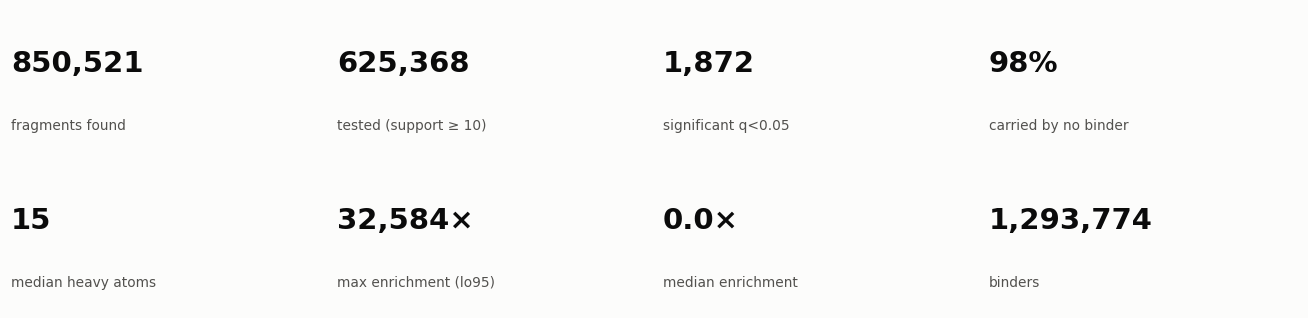

In [34]:
tested = frags[frags["tested"]]
sig = tested[tested["q_value"] < 0.05]
fig = stat_tiles([
    ("fragments found", f"{len(frags):,}"),
    (f"tested (support \u2265 {int(summary['min_count'])})", f"{len(tested):,}"),
    ("significant q<0.05", f"{len(sig):,}"),
    ("carried by no binder", f"{(frags.n_binder == 0).mean():.0%}"),
    ("median heavy atoms", f"{frags.hac.median():.0f}"),
    ("max enrichment (lo95)", f"{tested.enrichment_factor_lo95.max():,.0f}\u00d7"),
    ("median enrichment", f"{tested.enrichment_factor.replace([np.inf], np.nan).median():,.1f}\u00d7"),
    ("binders", f"{N_BIND:,}"),
])
plt.show()

## How enrichment is distributed

Most fragments sit near 1× — no preference either way. The question is how heavy
the right tail is.

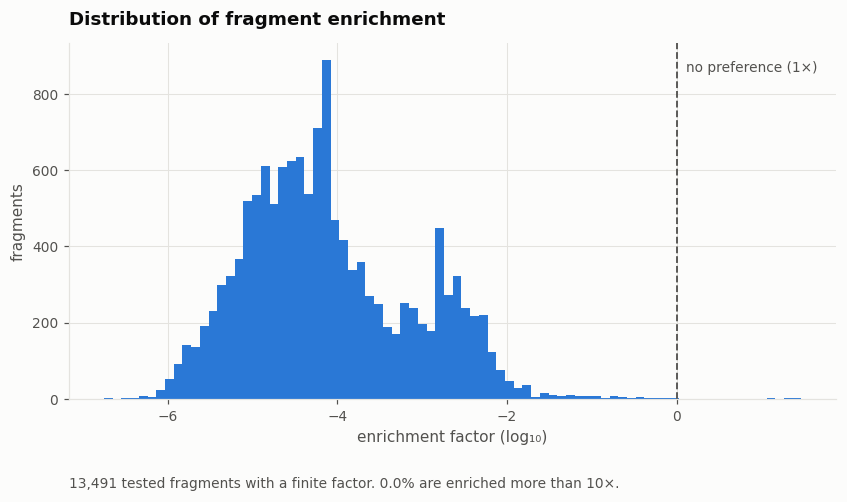

In [35]:
vals = finite(tested["binder_per_nonbinder"])
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(np.log10(vals), bins=80, color=SERIES[0], edgecolor="none")
ax.axvline(0, color=INK_SOFT, lw=1.2, ls="--")
ax.annotate("no preference (1\u00d7)", xy=(0, ax.get_ylim()[1]*0.92), xytext=(6, 0),
            textcoords="offset points", color=INK_SOFT, fontsize=9)
ax.set_xlabel("enrichment factor (log\u2081\u2080)")
ax.set_ylabel("fragments")
ax.set_title("Distribution of fragment enrichment")
strip_spines(ax)
caption(ax, f"{len(vals):,} tested fragments with a finite factor. "
            f"{(vals > 10).mean():.1%} are enriched more than 10\u00d7.")
plt.show()

## Enrichment against the evidence behind it

The point of the lower bound. High point-estimates cluster at low binder counts,
where they are least trustworthy; the bound pulls those back.

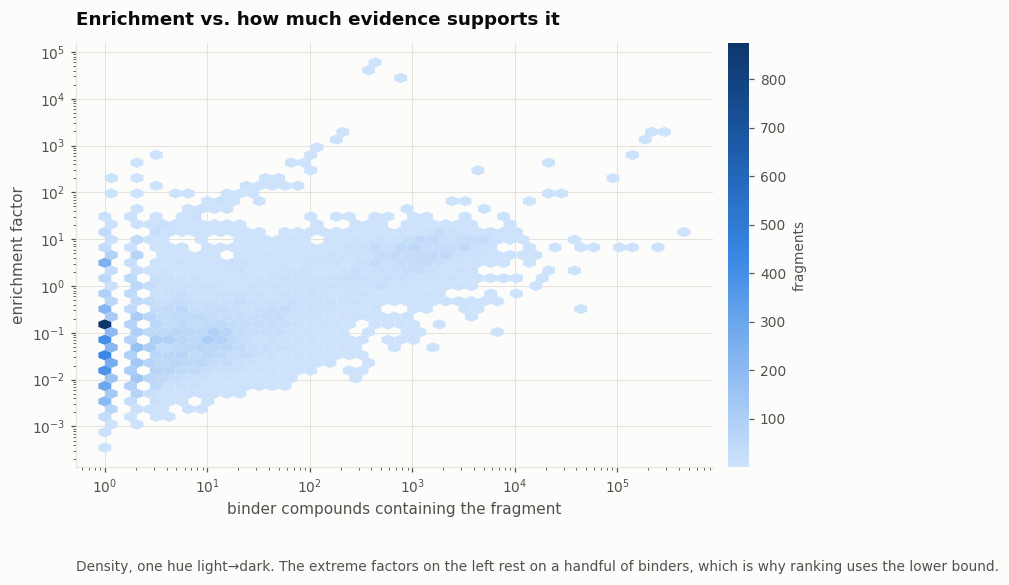

In [36]:
sub = tested[(tested.n_binder > 0) & np.isfinite(tested.enrichment_factor)]
fig, ax = plt.subplots(figsize=(9, 5))
hb = ax.hexbin(sub.n_binder, sub.enrichment_factor, xscale="log", yscale="log",
               gridsize=45, cmap=SEQUENTIAL, mincnt=1, linewidths=0)
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("fragments", color=INK_SOFT, fontsize=9)
cb.outline.set_visible(False)
ax.set_xlabel("binder compounds containing the fragment")
ax.set_ylabel("enrichment factor")
ax.set_title("Enrichment vs. how much evidence supports it")
strip_spines(ax)
caption(ax, "Density, one hue light\u2192dark. The extreme factors on the left rest on a "
            "handful of binders, which is why ranking uses the lower bound.")
plt.show()

## Point estimate vs. lower bound

Same fragments, both scales. Everything sits below the diagonal — the bound is
always the more conservative read, and it collapses hardest for thin evidence.

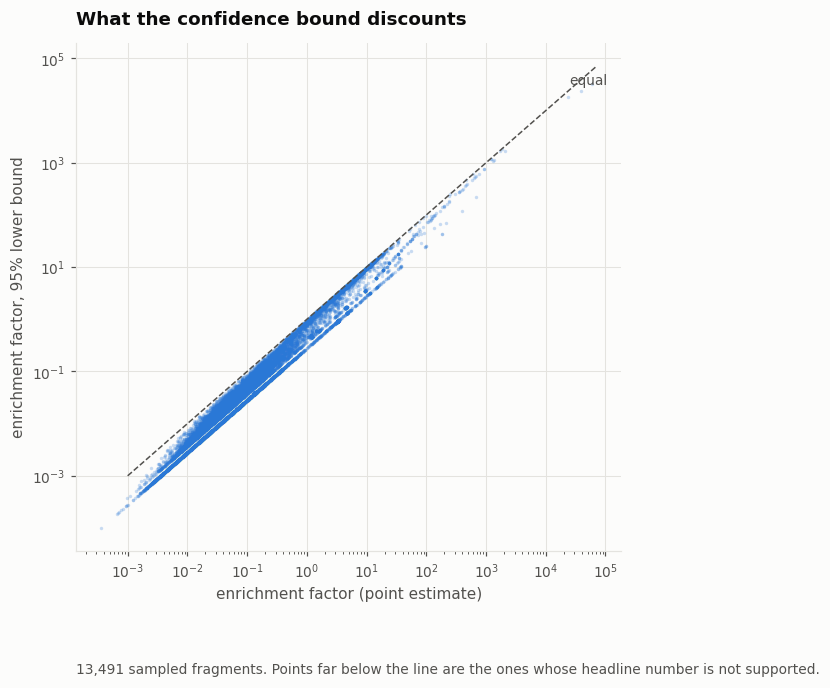

In [37]:
s = sub[sub.enrichment_factor_lo95 > 0].sample(min(30000, len(sub)), random_state=0)
fig, ax = plt.subplots(figsize=(6.4, 6))
ax.scatter(s.enrichment_factor, s.enrichment_factor_lo95, s=5, alpha=0.25,
           color=SERIES[0], linewidths=0)
lim = [max(1e-3, s.enrichment_factor_lo95.min()), s.enrichment_factor.max()*1.2]
ax.plot(lim, lim, color=INK_SOFT, lw=1, ls="--")
ax.annotate("equal", xy=(lim[1]*0.35, lim[1]*0.45), color=INK_SOFT, fontsize=9)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("enrichment factor (point estimate)")
ax.set_ylabel("enrichment factor, 95% lower bound")
ax.set_title("What the confidence bound discounts")
strip_spines(ax)
caption(ax, f"{len(s):,} sampled fragments. Points far below the line are the ones "
            "whose headline number is not supported.")
plt.show()

## Volcano

Effect size against significance. At this library size almost anything with
support becomes significant, so the useful axis is horizontal, not vertical.

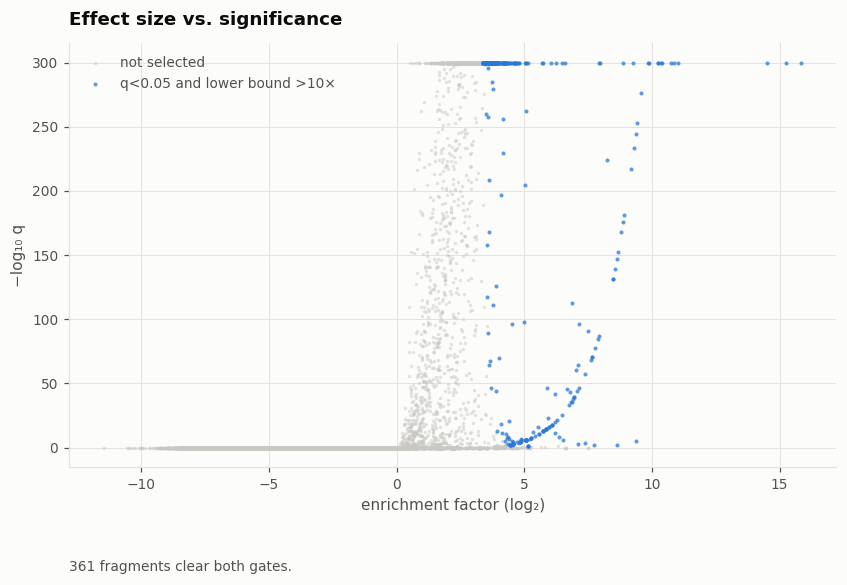

In [38]:
v = tested[np.isfinite(tested.enrichment_factor) & (tested.enrichment_factor > 0)].copy()
v["neglog_q"] = -np.log10(v["q_value"].clip(lower=1e-300))
hit = (v.q_value < 0.05) & (v.enrichment_factor_lo95 > 10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(np.log2(v.loc[~hit, "enrichment_factor"]), v.loc[~hit, "neglog_q"],
           s=5, color="#c9c8c3", alpha=0.5, linewidths=0, label="not selected")
ax.scatter(np.log2(v.loc[hit, "enrichment_factor"]), v.loc[hit, "neglog_q"],
           s=7, color=SERIES[0], alpha=0.75, linewidths=0,
           label="q<0.05 and lower bound >10\u00d7")
ax.set_xlabel("enrichment factor (log\u2082)")
ax.set_ylabel("\u2212log\u2081\u2080 q")
ax.set_title("Effect size vs. significance")
ax.legend(loc="upper left")
strip_spines(ax)
caption(ax, f"{int(hit.sum()):,} fragments clear both gates.")
plt.show()

## Does fragment size drive enrichment?

Worth checking before reading anything into the top of the list: if bigger
fragments score higher purely for being rarer, the ranking is partly measuring
size.

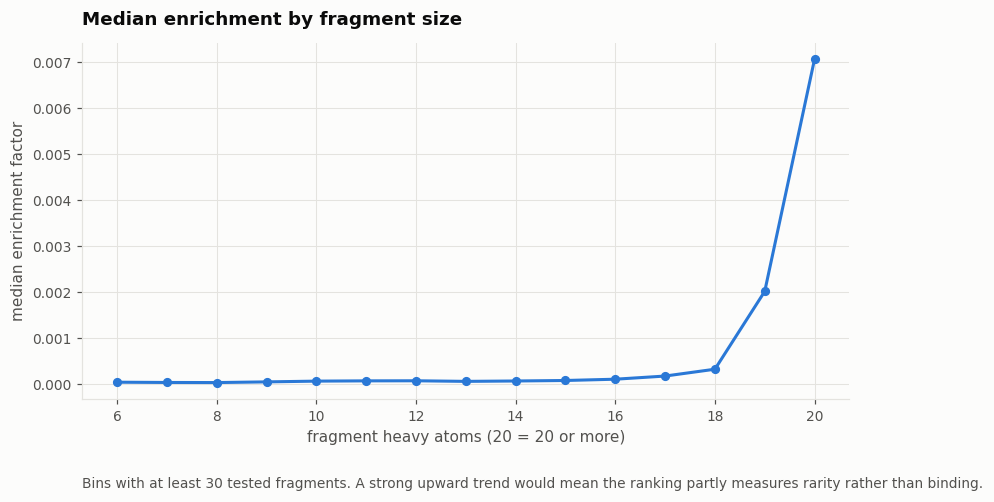

In [39]:
by_hac = (tested.assign(hac_bin=tested.hac.clip(upper=20))
          .groupby("hac_bin")["binder_per_nonbinder"]
          .apply(lambda x: np.median(finite(x)) if len(finite(x)) else np.nan))
counts = tested.assign(hac_bin=tested.hac.clip(upper=20)).groupby("hac_bin").size()
keep = counts[counts >= 30].index
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(by_hac.loc[keep].index, by_hac.loc[keep].values, color=SERIES[0], marker="o", ms=5)
ax.set_xlabel("fragment heavy atoms (20 = 20 or more)")
ax.set_ylabel("median enrichment factor")
ax.set_title("Median enrichment by fragment size")
strip_spines(ax)
caption(ax, "Bins with at least 30 tested fragments. A strong upward trend would mean "
            "the ranking partly measures rarity rather than binding.")
plt.show()

## Top fragments

Ranked on the lower bound. `binder_per_nonbinder` is the raw ratio; divide it by
the library baseline printed above and you get `enrichment_factor`.

In [40]:
cols = ["frag_name", "frag_smiles", "hac", "n_binder", "n_nonbinder",
        "binder_per_nonbinder", "enrichment_factor", "enrichment_factor_lo95", "q_value"]
top = tested.sort_values('binder_per_nonbinder', ascending=False).head(25)
top[cols].reset_index(drop=True)

,frag_name,frag_smiles,hac,n_binder,n_nonbinder,binder_per_nonbinder,enrichment_factor,enrichment_factor_lo95,q_value
0,F316408,[16*]c1cnc2ccc(C#Cc3cc4ccccc4s3)cc2c1,21,414,14,29.550321,59324.532287,32584.253517,0.000000e+00
1,F189001,[14*]c1[nH]nc2ccc(C#Cc3cc4ccccc4s3)cc12,20,407,21,19.371728,38880.973657,23994.847222,0.000000e+00
2,F137303,[9*]n1cnc2ccc(C#Cc3cc4ccccc4s3)cc2c1=O,22,788,68,11.586531,23247.664116,17906.273877,0.000000e+00
3,F221715,[14*]c1cncc(C#Cc2cc3n(n2)CCCC3)n1,17,217,211,1.028387,2063.190341,1706.818575,0.000000e+00
4,F003496,[5*]Nc1cc(C2CC2)[nH]n1,9,251899,268451,0.938343,1882.449936,1872.766981,0.000000e+00
5,F003427,[5*]Nc1cc(CC2CC2)[nH]n1,10,242062,283553,0.853675,1712.593882,1703.808805,0.000000e+00
6,F189052,[14*]c1[nH]nc2ccc(C#Cc3ccc(CCC)s3)cc12,19,173,255,0.678405,1361.030759,1124.167070,0.000000e+00
7,F213899,[14*]c1cc2nccc(C#Cc3cc4ccccc4s3)c2s1,20,168,260,0.646129,1296.277406,1069.919990,0.000000e+00
8,F003154,[5*]Nc1cc(CC)n[nH]1,8,209117,349327,0.598628,1200.934173,1194.781213,0.000000e+00
9,F003497,[5*]Nc1cc(C2CCC2)[nH]n1,10,194570,325780,0.597244,1198.156305,1191.771208,0.000000e+00


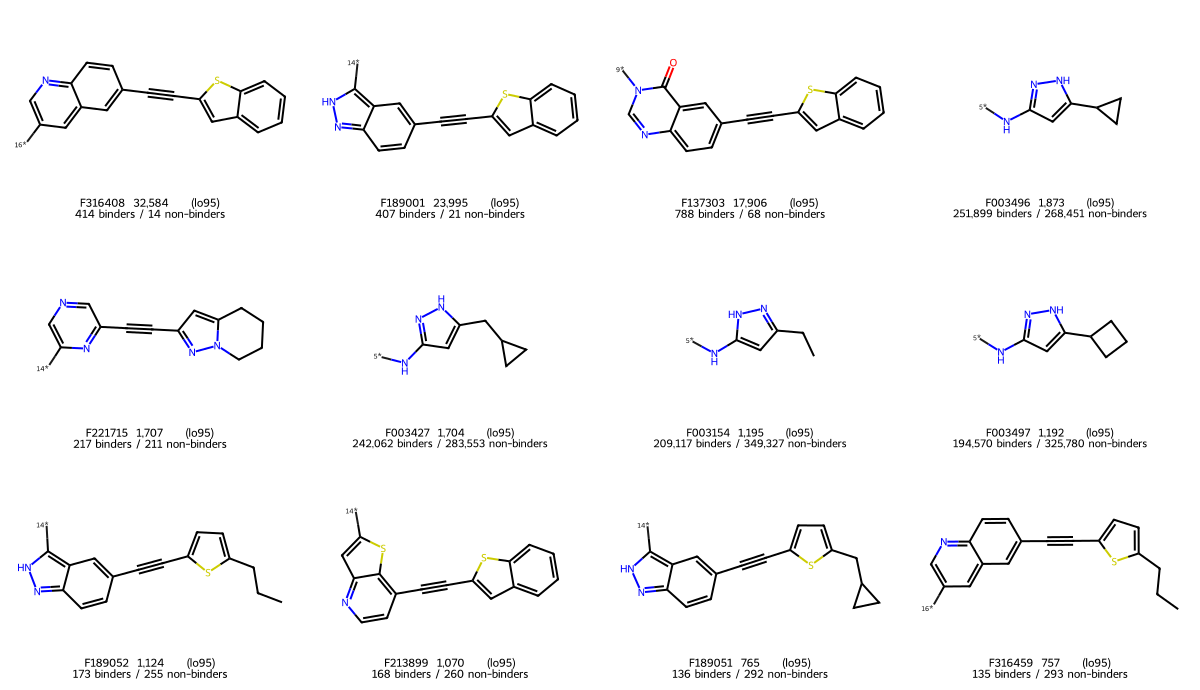

In [22]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
RDLogger.DisableLog("rdApp.*")

show = top.head(12)
mols, legends = [], []
for _, r in show.iterrows():
    m = Chem.MolFromSmiles(r.frag_smiles)
    if m is None:
        continue
    mols.append(m)
    legends.append(f"{r.frag_name}  {r.enrichment_factor_lo95:,.0f}\u00d7 (lo95)\n"
                   f"{int(r.n_binder):,} binders / {int(r.n_nonbinder):,} non-binders")
draw_grid(mols, legends, mols_per_row=4, sub_img_size=(300, 230))

## Export

In [23]:
out = Path("../reports"); out.mkdir(exist_ok=True)
tested.sort_values("enrichment_factor_lo95", ascending=False)[cols].head(1000) \
    .to_csv(out / "top_fragments.csv", index=False)
print("wrote", (out / "top_fragments.csv").resolve())

wrote /home/aserrano/frags-DEL/BRICS_fragmentation/reports/top_fragments.csv
